In [1]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import os
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook", font_scale=1.1)

plt.rcParams.update({'figure.dpi': 120, 'font.family': 'sans-serif'})
sns.set_theme(style="whitegrid")

In [2]:
def load_and_preprocess_data(filepath: str, is_real_dataset: bool = False) -> tuple:
    """
    Parses the dataset using the empirically observed delimiters, isolates
    feature matrices from meta-labels, and applies Z-score standardization.
    """
    # Dynamic delimiter assignment based on file inspection
    delimiter = ';' if is_real_dataset else ','
    
    df = pd.read_csv(filepath, sep=delimiter)
    
    if is_real_dataset:
        # A2-real: 5 features, 1 location, 1 class
        feature_cols = df.columns[:-2]
        X_raw = df[feature_cols].values
        metadata = {
            'labels': df.iloc[:, -1].values,
            'locations': df.iloc[:, -2].values
        }
    else:
        # A2-synthetic: 4 features, 1 class
        feature_cols = df.columns[:-1]
        X_raw = df[feature_cols].values
        metadata = {'labels': df.iloc[:, -1].values}
        
    # Apply Z-score standardization: (x - mu) / sigma
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_raw)
    
    return X_scaled, metadata, feature_cols

# init tensor variables
X_syn, meta_syn, cols_syn = load_and_preprocess_data('A2-synthetic.txt', is_real_dataset=False)
X_real, meta_real, cols_real = load_and_preprocess_data('A2-real.txt', is_real_dataset=True)

print(f"Synthetic tensor -> X shape: {X_syn.shape} (Expected: 360, 4)")
print(f"Real tensor      -> X shape: {X_real.shape} (Expected: 333, 5)")

Synthetic tensor -> X shape: (360, 4) (Expected: 360, 4)
Real tensor      -> X shape: (333, 5) (Expected: 333, 5)


--- PCA Analysis: Synthetic Dataset ---


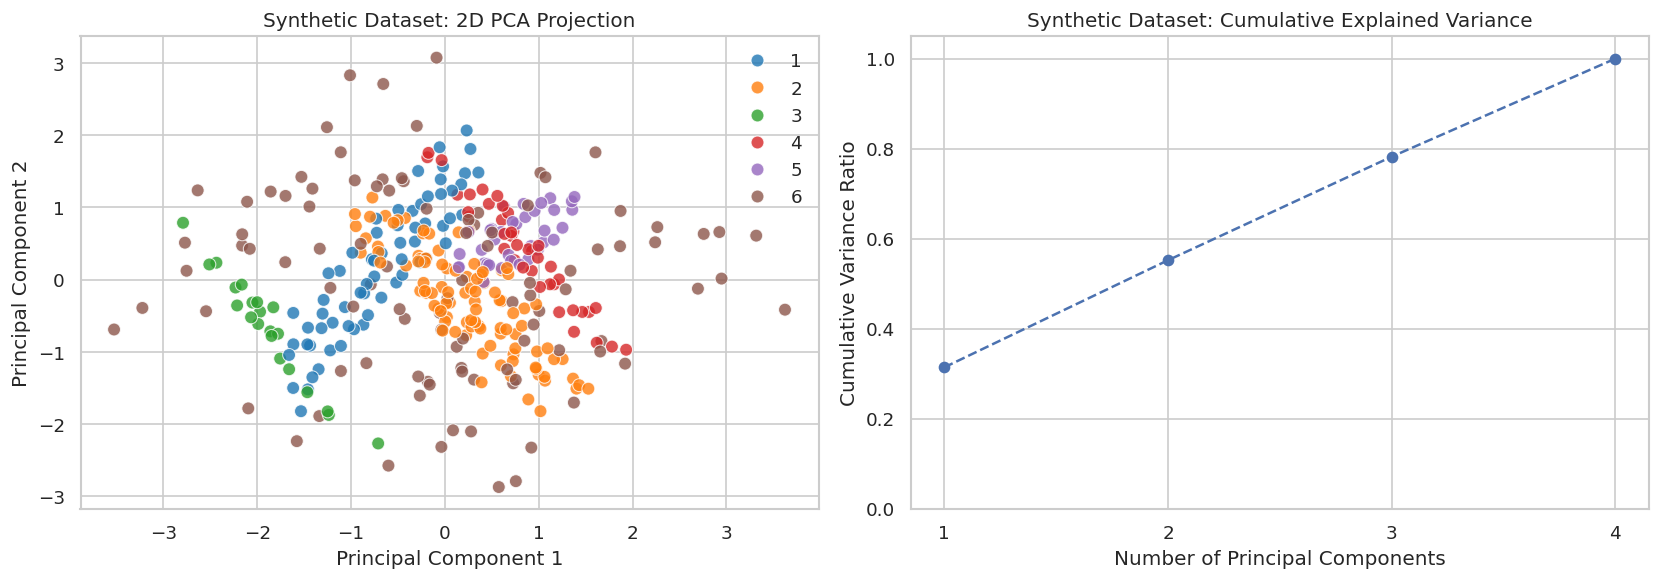


--- PCA Analysis: Real Dataset ---


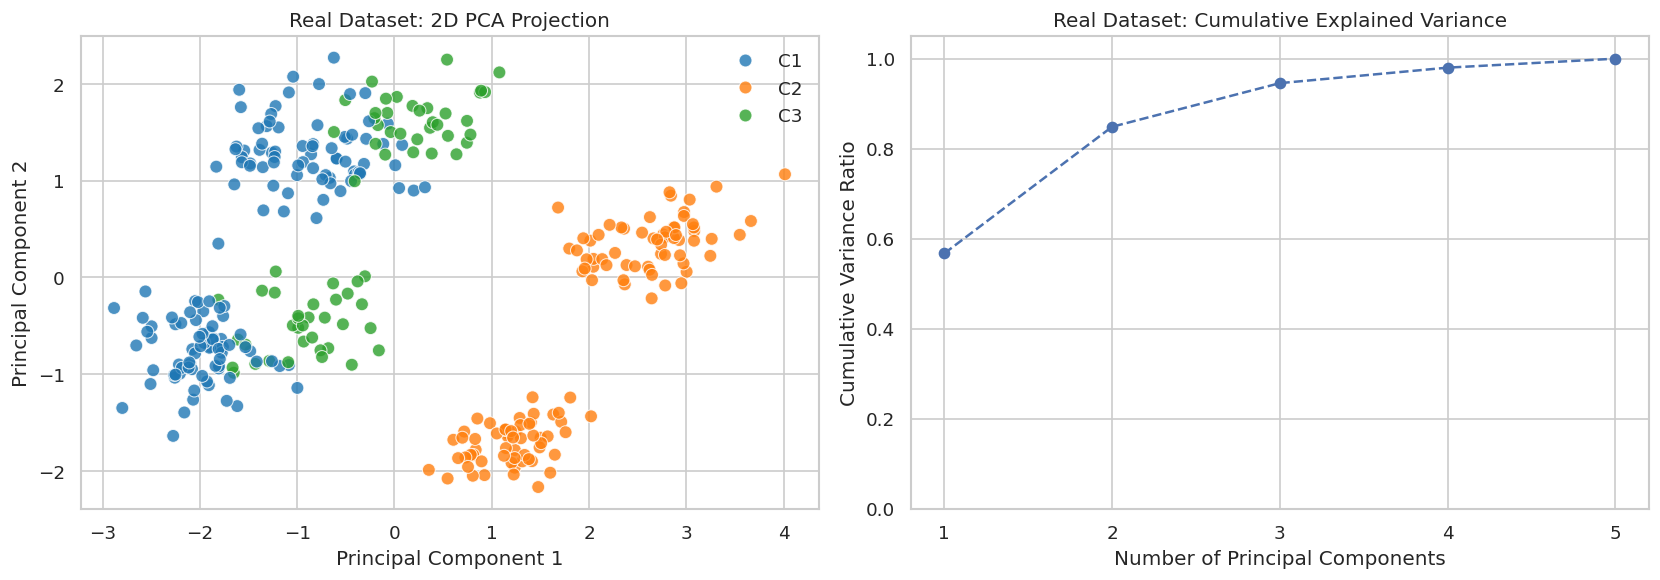

In [3]:
#PCA
from sklearn.decomposition import PCA

def execute_pca_pipeline(X: np.ndarray, labels: np.ndarray, dataset_name: str) -> np.ndarray:
    """
    Computes PCA transformation, plots the 2D projection colored by class,
    and generates the cumulative explained variance scree plot.
    """
    # Instantiate PCA keeping all components to calculate full variance spectrum
    pca = PCA()
    X_pca_full = pca.fit_transform(X)

    # 2D projection requirement
    X_pca_2d = X_pca_full[:, :2]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # Plot 1: 2D Latent Space Projection
    sns.scatterplot(
        x=X_pca_2d[:, 0],
        y=X_pca_2d[:, 1],
        hue=labels,
        palette='tab10',
        ax=axes[0],
        s=60,
        alpha=0.8,
        legend='full'
    )
    axes[0].set_title(f'{dataset_name}: 2D PCA Projection')
    axes[0].set_xlabel('Principal Component 1')
    axes[0].set_ylabel('Principal Component 2')

    # Plot 2: Scree Plot (Cumulative Variance)
    cumulative_variance = np.cumsum(pca.explained_variance_ratio_)
    axes[1].plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', linestyle='--')
    axes[1].set_title(f'{dataset_name}: Cumulative Explained Variance')
    axes[1].set_xlabel('Number of Principal Components')
    axes[1].set_ylabel('Cumulative Variance Ratio')
    axes[1].set_ylim(0, 1.05)
    axes[1].set_xticks(range(1, len(cumulative_variance) + 1))

    plt.tight_layout()
    plt.show()

    return X_pca_2d

print("--- PCA Analysis: Synthetic Dataset ---")
X_syn_pca = execute_pca_pipeline(X_syn, meta_syn['labels'], "Synthetic Dataset")

print("\n--- PCA Analysis: Real Dataset ---")
X_real_pca = execute_pca_pipeline(X_real, meta_real['labels'], "Real Dataset")

--- t-SNE Optimization: Synthetic Dataset ---


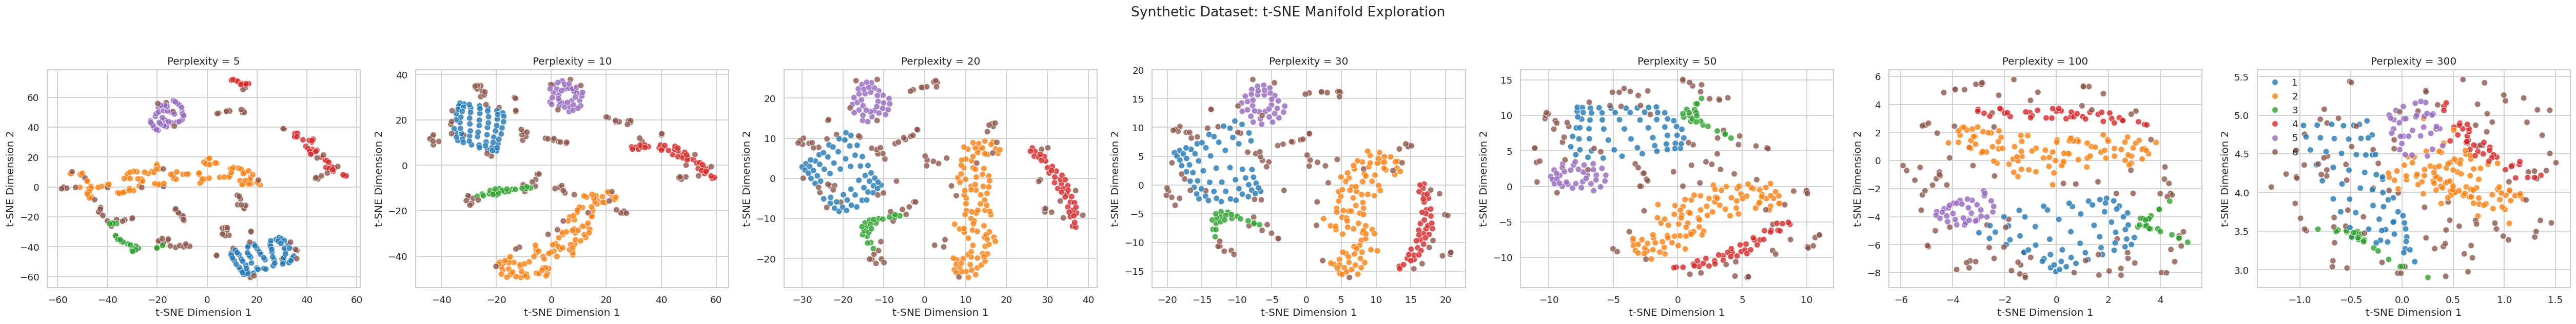


--- t-SNE Optimization: Real Dataset ---


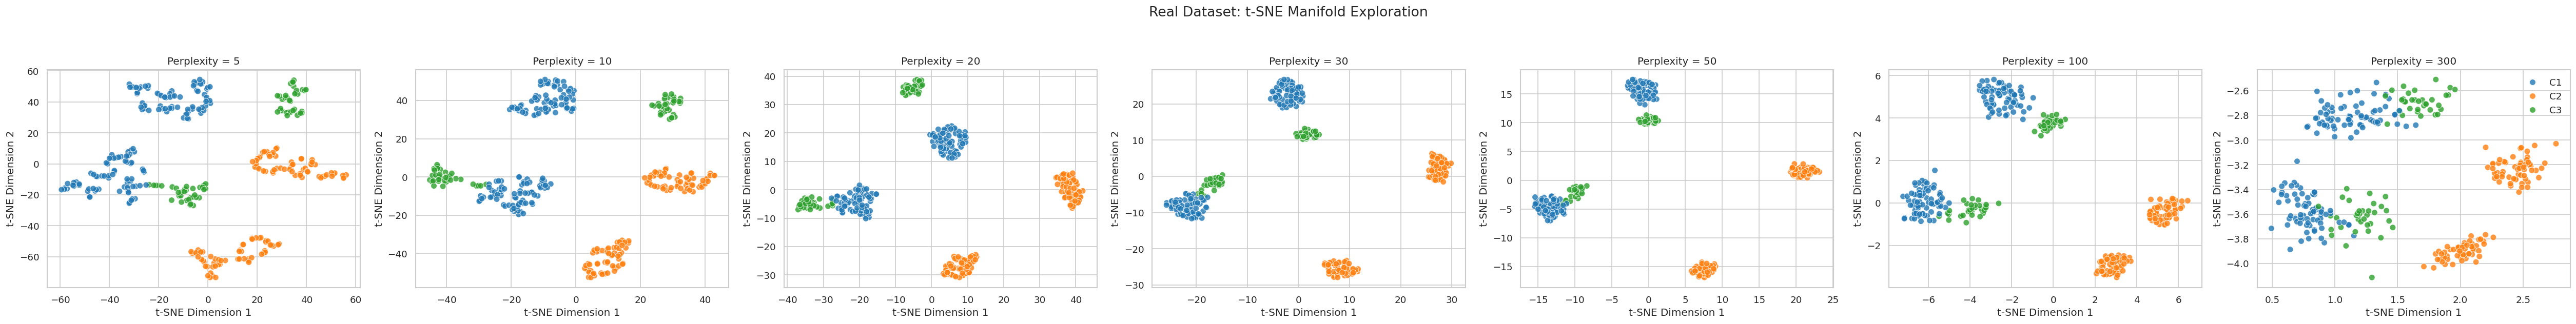

In [4]:
#t-SNE
from sklearn.manifold import TSNE

def evaluate_tsne_perplexities(X: np.ndarray, labels: np.ndarray, dataset_name: str, perplexities: list, save_dir: str = './plots'):
    """
    Computes and plots t-SNE 2D projections for a given list of perplexity values.
    Demonstrates the impact of the effective neighborhood size on local topology.
    """
    n_plots = len(perplexities)
    # Define a 1xN grid for the subplots based on the number of perplexities
    fig, axes = plt.subplots(1, n_plots, figsize=(6 * n_plots, 5))

    if n_plots == 1:
        axes = [axes] # ensure iterable if only one perplexity is passed

    for i, perplexity in enumerate(perplexities):
        tsne = TSNE(
            n_components=2,
            perplexity=perplexity,
            random_state=42,
            init='pca',
            learning_rate='auto'
        )

        # fit and transform the standardized feature matrix
        X_tsne = tsne.fit_transform(X)

        # plot the 2D latent space
        sns.scatterplot(
            x=X_tsne[:, 0],
            y=X_tsne[:, 1],
            hue=labels,
            palette='tab10',
            ax=axes[i],
            s=50,
            alpha=0.8,
            legend='full' if i == n_plots - 1 else False
        )

        axes[i].set_title(f'Perplexity = {perplexity}')
        axes[i].set_xlabel('t-SNE Dimension 1')
        axes[i].set_ylabel('t-SNE Dimension 2')

    fig.suptitle(f'{dataset_name}: t-SNE Manifold Exploration', fontsize=16, y=1.05)
    plt.tight_layout()

    filename = f"{dataset_name.replace(' ', '_').lower()}_tsne_grid.png"
    filepath = os.path.join(save_dir, filename)
    fig.savefig(filepath, dpi=300, bbox_inches='tight')

    plt.show()

# define hyperparameter grid: extremely local, standard, and global limits
perplexity_grid = [5, 10, 20, 30, 50, 100, 300]

print("--- t-SNE Optimization: Synthetic Dataset ---")
evaluate_tsne_perplexities(X_syn, meta_syn['labels'], "Synthetic Dataset", perplexity_grid)

print("\n--- t-SNE Optimization: Real Dataset ---")
evaluate_tsne_perplexities(X_real, meta_real['labels'], "Real Dataset", perplexity_grid)

--- K-Means Evaluation: Synthetic Dataset ---


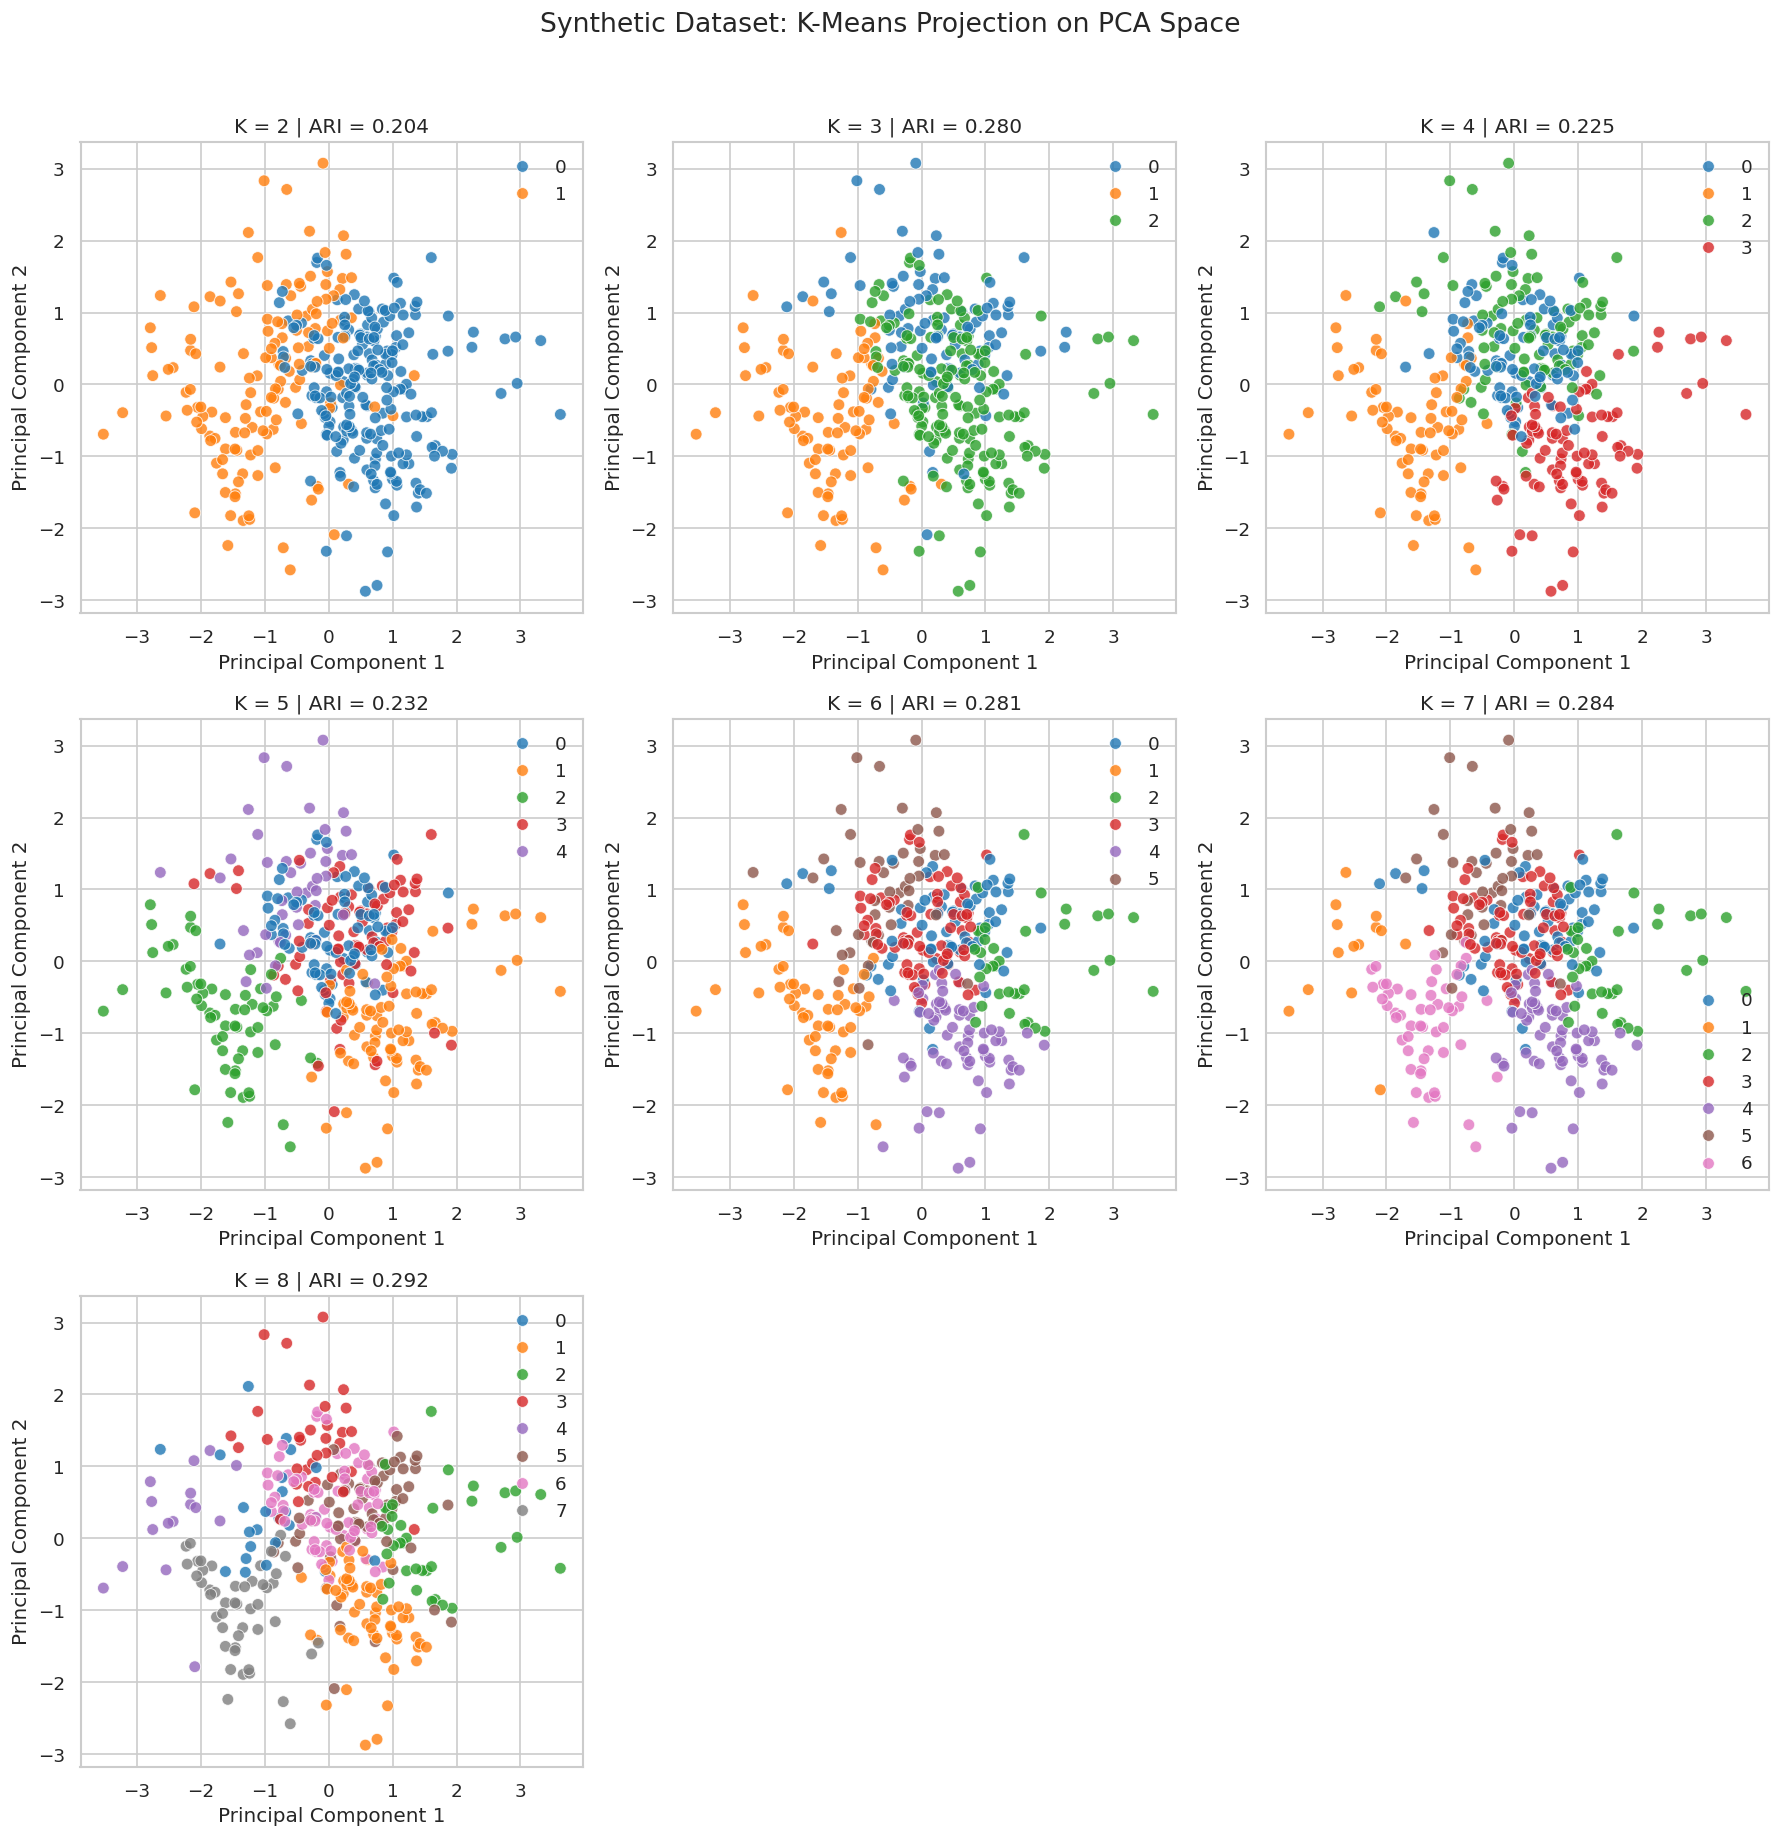

--- ARI Benchmark Summary for Synthetic Dataset ---
K = 2: ARI = 0.2041
K = 3: ARI = 0.2796
K = 4: ARI = 0.2246
K = 5: ARI = 0.2321
K = 6: ARI = 0.2814
K = 7: ARI = 0.2837
K = 8: ARI = 0.2923

--- K-Means Evaluation: Real Dataset ---


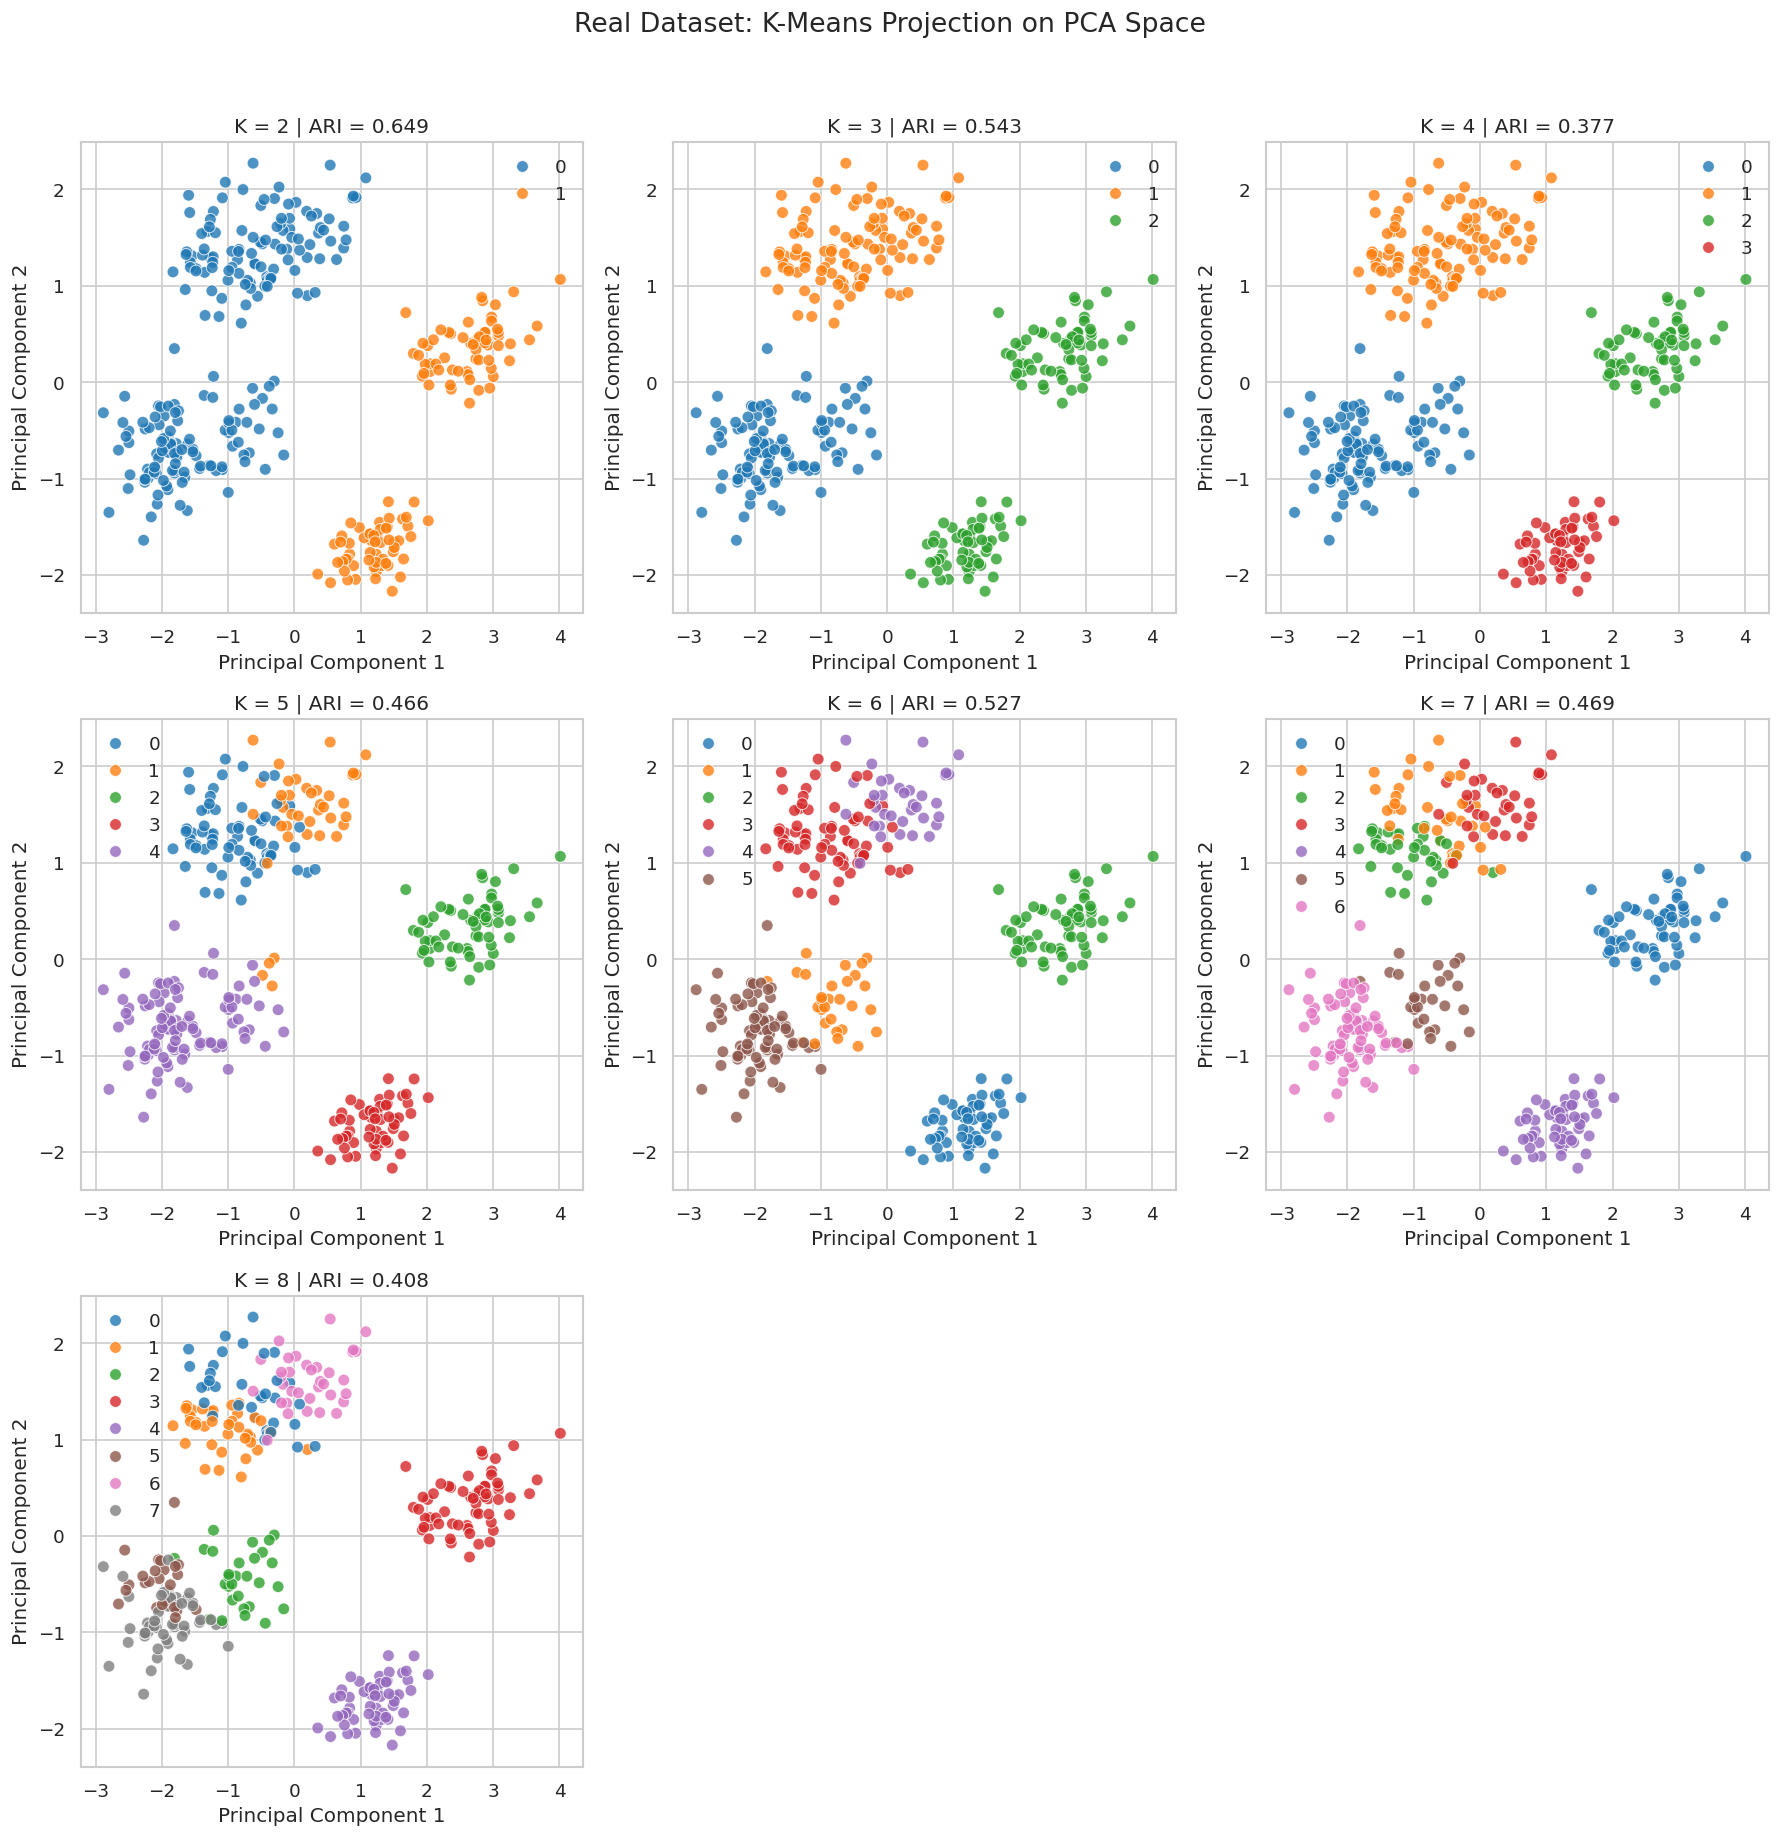

--- ARI Benchmark Summary for Real Dataset ---
K = 2: ARI = 0.6486
K = 3: ARI = 0.5427
K = 4: ARI = 0.3767
K = 5: ARI = 0.4661
K = 6: ARI = 0.5266
K = 7: ARI = 0.4689
K = 8: ARI = 0.4078


In [13]:
# k-MEANS
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score

def evaluate_kmeans_on_pca(X: np.ndarray, X_pca: np.ndarray, real_labels: np.ndarray, dataset_name: str, k_range: range, save_dir: str = './plots'):
    """
    Applies K-Means clustering across a range of k values, computes the Adjusted Rand Index (ARI)
    against ground truth, and plots the assigned clusters onto the 2D PCA latent space.
    """
    n_plots = len(k_range)
    cols = 3
    rows = int(np.ceil(n_plots / cols))

    fig, axes = plt.subplots(rows, cols, figsize=(5 * cols, 5 * rows))
    axes = axes.flatten() # flatten to iterate easily

    ari_scores = []

    for i, k in enumerate(k_range):
        # initialize K-Means
        kmeans = KMeans(n_clusters=k, random_state=42, n_init='auto', init="random" if dataset_name == "Synthetic Dataset" else "k-means++")

        # Fit on high-dimensional scaled space X, get predicted cluster assignments
        predicted_clusters = kmeans.fit_predict(X)

        # comparison: Compute ARI between true labels and K-Means clusters
        ari = adjusted_rand_score(real_labels, predicted_clusters)
        ari_scores.append((k, ari))

        # Scatter plot over PCA coordinates (from Module 3)
        sns.scatterplot(
            x=X_pca[:, 0],
            y=X_pca[:, 1],
            hue=predicted_clusters,
            palette='tab10',
            ax=axes[i],
            s=50,
            alpha=0.8,
            legend='full'
        )

        axes[i].set_title(f'K = {k} | ARI = {ari:.3f}')
        axes[i].set_xlabel('Principal Component 1')
        axes[i].set_ylabel('Principal Component 2')

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    fig.suptitle(f'{dataset_name}: K-Means Projection on PCA Space', fontsize=16, y=1.02)
    plt.tight_layout()

    filename = f"{dataset_name.replace(' ', '_').lower()}_kmeans_pca.png"
    filepath = os.path.join(save_dir, filename)
    fig.savefig(filepath, dpi=300, bbox_inches='tight')

    plt.show()

    # statistical summary
    print(f"--- ARI Benchmark Summary for {dataset_name} ---")
    for k, ari in ari_scores:
        print(f"K = {k}: ARI = {ari:.4f}")

    return ari_scores

# evaluate K from 2 to 8 to cover the underlying ground truth of both datasets (Synthetic has 6 true classes, Real has 3 true classes)
k_search_space = range(2, 9)

print("--- K-Means Evaluation: Synthetic Dataset ---")
ari_syn = evaluate_kmeans_on_pca(
    X=X_syn,
    X_pca=X_syn_pca,
    real_labels=meta_syn['labels'],
    dataset_name="Synthetic Dataset",
    k_range=k_search_space
)

print("\n--- K-Means Evaluation: Real Dataset ---")
ari_real = evaluate_kmeans_on_pca(
    X=X_real,
    X_pca=X_real_pca,
    real_labels=meta_real['labels'],
    dataset_name="Real Dataset",
    k_range=k_search_space
)

Plot saved successfully at: plots/synthetic_dataset_ahc.png


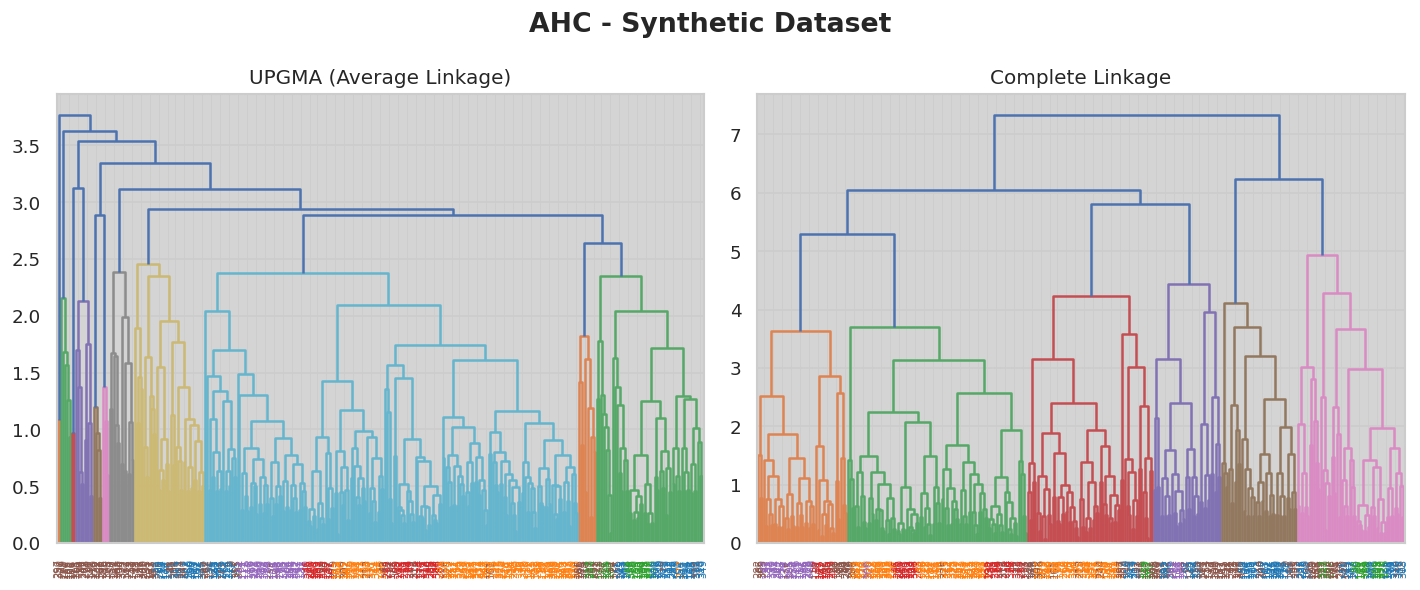

Plot saved successfully at: plots/real_dataset_ahc.png


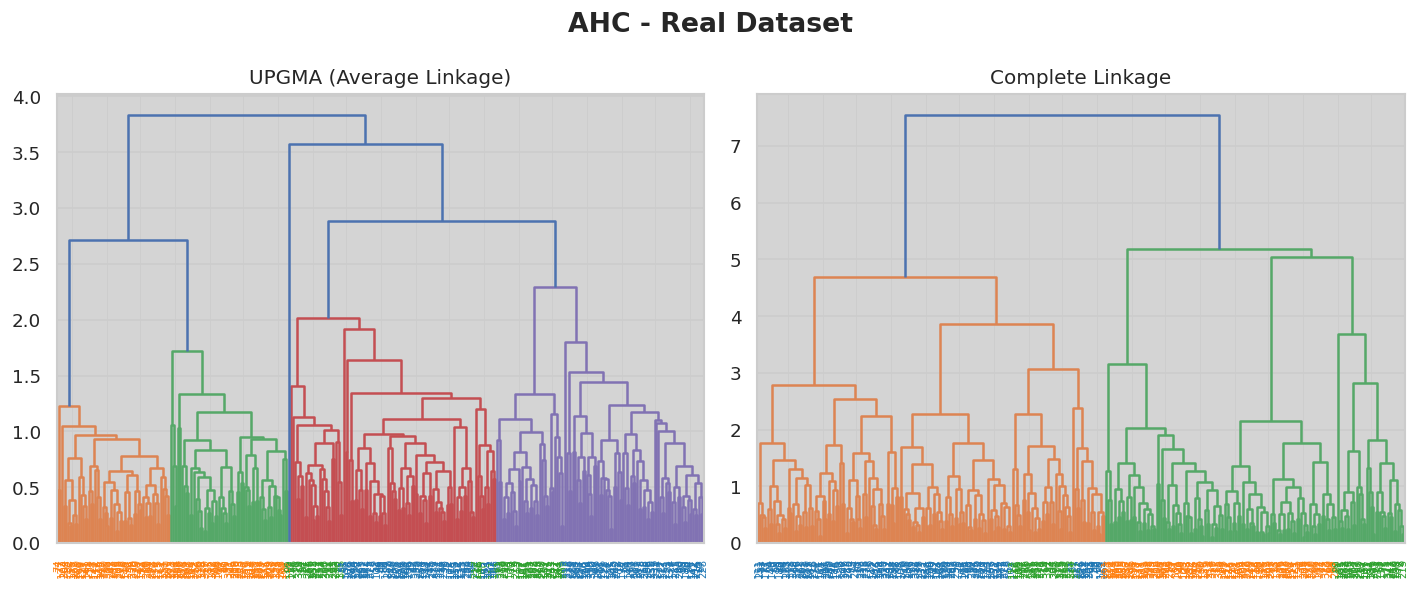

In [6]:
# AHC
from scipy.cluster.hierarchy import linkage, dendrogram
import os

def plot_ahc(X, labels, title, filename):
    """
    Computes Agglomerative Hierarchical Clustering (AHC) and plots the dendrograms.
    The resulting plot is saved in the 'plots' directory with a user-defined filename.
    """
    # 1. Ensure the output directory exists
    if not os.path.exists('plots'):
        os.makedirs('plots')
        
    # 2. Compute the linkage matrices
    Z_avg = linkage(X, method='average', metric='euclidean')
    Z_comp = linkage(X, method='complete', metric='euclidean')
    
    # 3. Setup the figure
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # 4. Configure colors for the true classes
    labels = np.array(labels)
    unique_classes = np.unique(labels)
    palette = sns.color_palette("tab10", len(unique_classes))
    color_map = {cls: palette[i] for i, cls in enumerate(unique_classes)}
    
    def set_leaf_colors(ax):
        """Helper to color the leaf labels based on ground-truth classes."""
        for label in ax.get_xticklabels():
            idx = int(label.get_text())
            label.set_color(color_map[labels[idx]])
    
    # 5. Plot Average Linkage (UPGMA)
    dendrogram(Z_avg, ax=axes[0], labels=np.arange(len(X)), leaf_rotation=90, leaf_font_size=6)
    axes[0].set_title('UPGMA (Average Linkage)')
    set_leaf_colors(axes[0])
    
    # 6. Plot Complete Linkage
    dendrogram(Z_comp, ax=axes[1], labels=np.arange(len(X)), leaf_rotation=90, leaf_font_size=6)
    axes[1].set_title('Complete Linkage')
    set_leaf_colors(axes[1])
    
    # 7. Final layout adjustments
    fig.suptitle(title, fontsize=16, fontweight='bold')
    plt.tight_layout()
    
    # 8. Save the figure
    save_path = os.path.join('plots', filename)
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Plot saved successfully at: {save_path}")
    
    plt.show()

plot_ahc(
    X=X_syn, 
    labels=meta_syn['labels'], 
    title="AHC - Synthetic Dataset", 
    filename="synthetic_dataset_ahc.png"
)

plot_ahc(
    X=X_real, 
    labels=meta_real['labels'], 
    title="AHC - Real Dataset", 
    filename="real_dataset_ahc.png"
)

Training Sequential PyTorch Autoencoder for: Autoencoder - Synthetic Dataset...
Training completed. Final MSE Loss: 0.2900
Plot saved successfully at: plots/synthetic_autoencoder.png



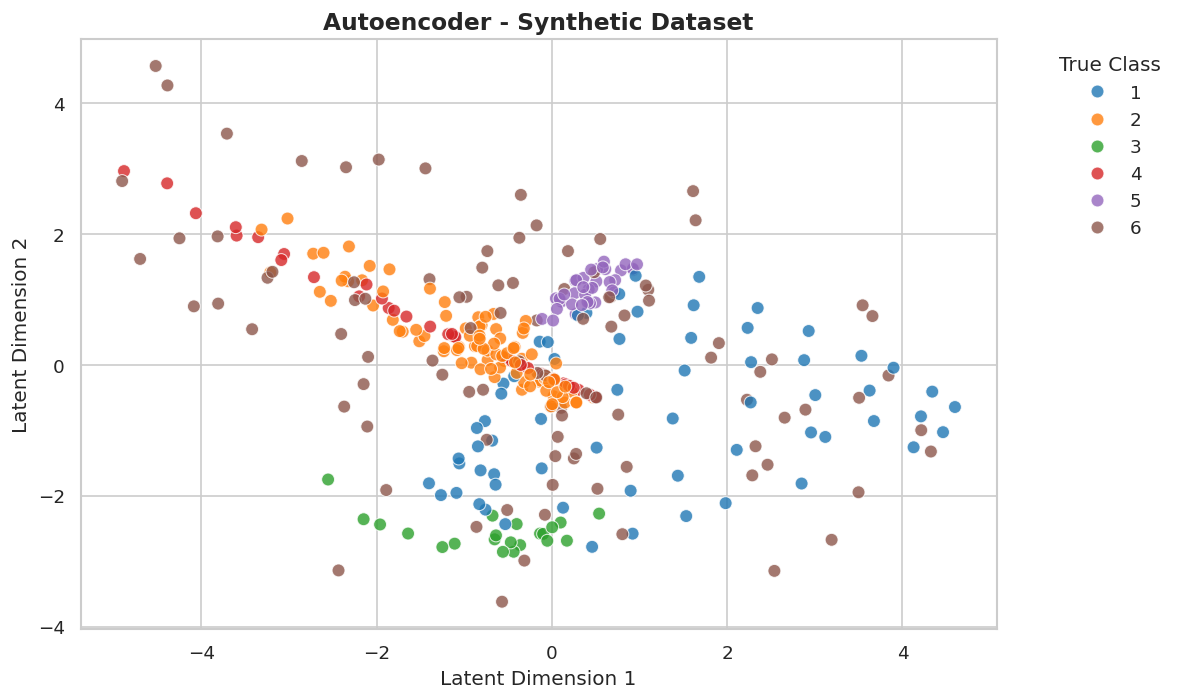

Training Sequential PyTorch Autoencoder for: Autoencoder - Real Dataset...
Training completed. Final MSE Loss: 0.0601
Plot saved successfully at: plots/real_autoencoder.png



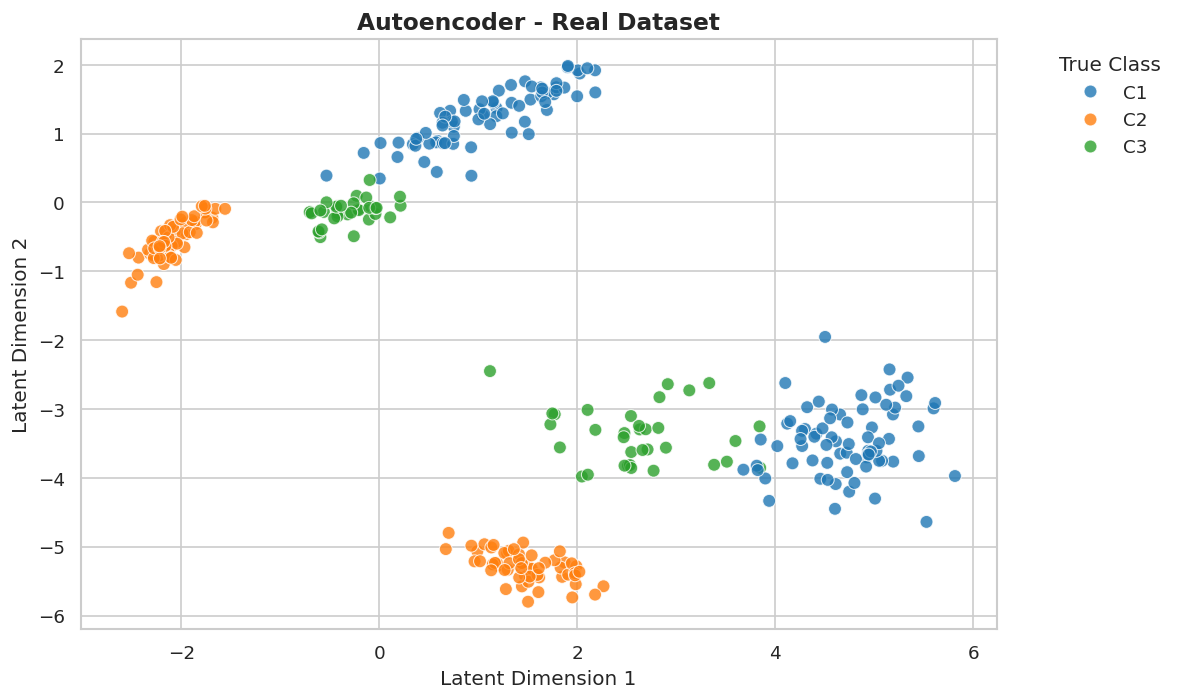

In [7]:
# AUTOENCODER
import torch
import torch.nn as nn
import torch.optim as optim

def train_and_plot_autoencoder_simple(X, labels, title, filename, input_dim):
    """
    Trains a PyTorch Autoencoder using a purely sequential approach (no classes) 
    and plots the 2D latent space projection.
    The resulting plot is saved in the 'plots' directory.
    """
    if not os.path.exists('plots'):
        os.makedirs('plots')
        
    X_tensor = torch.FloatTensor(X)
    labels = np.array(labels)
    
    # --- 1. Sequential Model Definition ---
    # Instead of a class, we stack all layers sequentially.
    # We must remember the indices to extract the bottleneck later.
    autoencoder = nn.Sequential(
        # -- Encoder --
        nn.Linear(input_dim, 8),   # Index 0
        nn.ReLU(),                 # Index 1
        nn.Linear(8, 2),           # Index 2: THE BOTTLENECK (2D)
        
        # -- Decoder --
        nn.Linear(2, 8),           # Index 3
        nn.ReLU(),                 # Index 4
        nn.Linear(8, input_dim)    # Index 5
    )
    
    criterion = nn.MSELoss()
    optimizer = optim.Adam(autoencoder.parameters(), lr=0.01) 
    
    # --- 2. Training Loop ---
    print(f"Training Sequential PyTorch Autoencoder for: {title}...")
    epochs = 500
    autoencoder.train() 
    
    for epoch in range(epochs):
        optimizer.zero_grad()
        # Pass data through the entire sequential network
        outputs = autoencoder(X_tensor) 
        loss = criterion(outputs, X_tensor)
        loss.backward()
        optimizer.step()
        
    print(f"Training completed. Final MSE Loss: {loss.item():.4f}")
    
    # --- 3. Latent Space Extraction (The "Trick") ---
    autoencoder.eval()
    with torch.no_grad():
        # We extract the 2D representation by slicing the sequential model.
        # autoencoder[:3] takes only the layers at index 0, 1, and 2.
        encoder_only = autoencoder[:3]
        X_2d = encoder_only(X_tensor).numpy()
        
    # --- 4. Visualization Setup ---
    fig, ax = plt.subplots(figsize=(10, 6))
    
    sns.scatterplot(
        x=X_2d[:, 0], 
        y=X_2d[:, 1], 
        hue=labels, 
        palette='tab10', 
        s=60, 
        alpha=0.8,
        edgecolor='w',
        ax=ax
    )
    
    ax.set_title(title, fontsize=14, fontweight='bold')
    ax.set_xlabel('Latent Dimension 1')
    ax.set_ylabel('Latent Dimension 2')
    
    ax.legend(title='True Class', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    
    # --- 5. Save the figure ---
    save_path = os.path.join('plots', filename)
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Plot saved successfully at: {save_path}\n")
    
    plt.show()

# --- Execution Block ---

train_and_plot_autoencoder_simple(
    X=X_syn, 
    labels=meta_syn['labels'], 
    title="Autoencoder - Synthetic Dataset", 
    filename="synthetic_autoencoder.png",
    input_dim=4
)

train_and_plot_autoencoder_simple(
    X=X_real, 
    labels=meta_real['labels'], 
    title="Autoencoder - Real Dataset", 
    filename="real_autoencoder.png",
    input_dim=5
)

Training SOM for SOM U-Matrix Visualization...
Plot saved successfully at: plots/synthetic_som.png



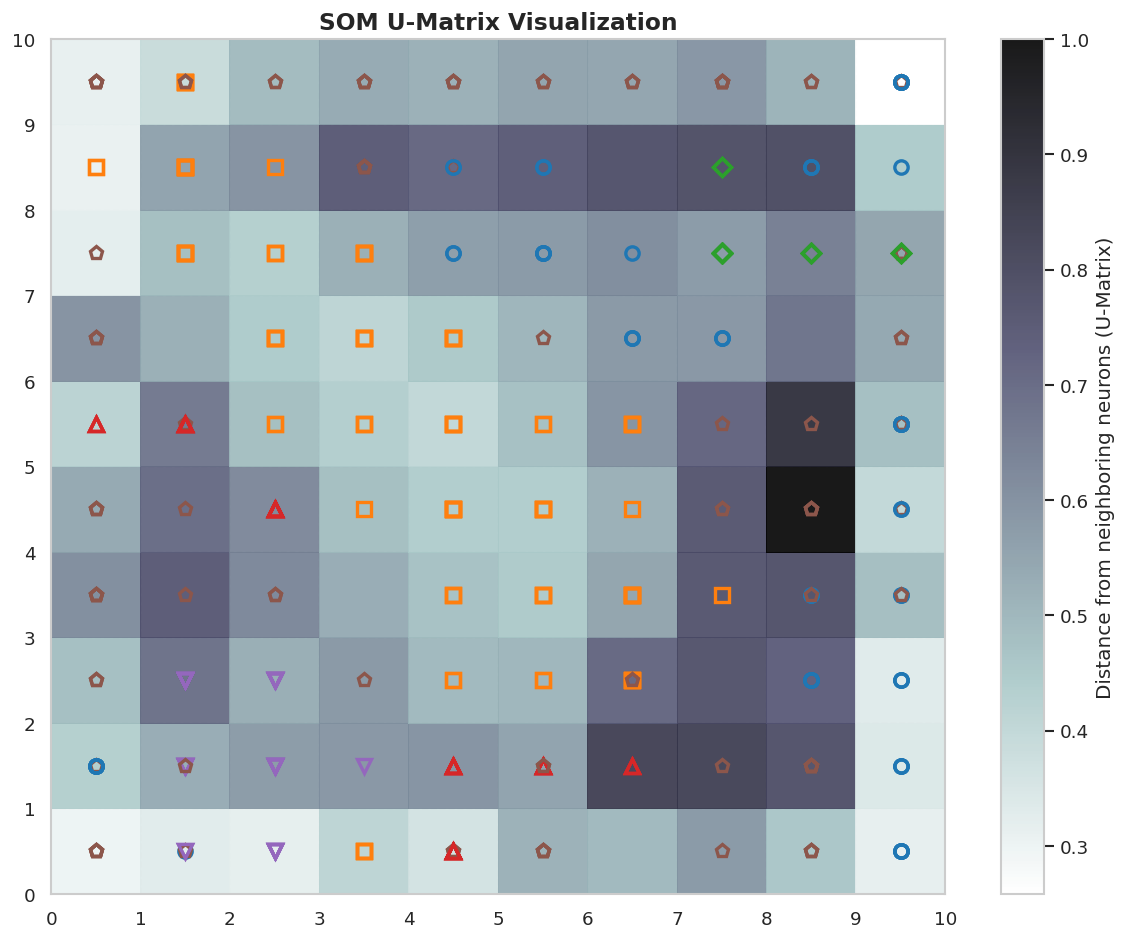

Training SOM for SOM U-Matrix Visualization...
Plot saved successfully at: plots/real_som.png



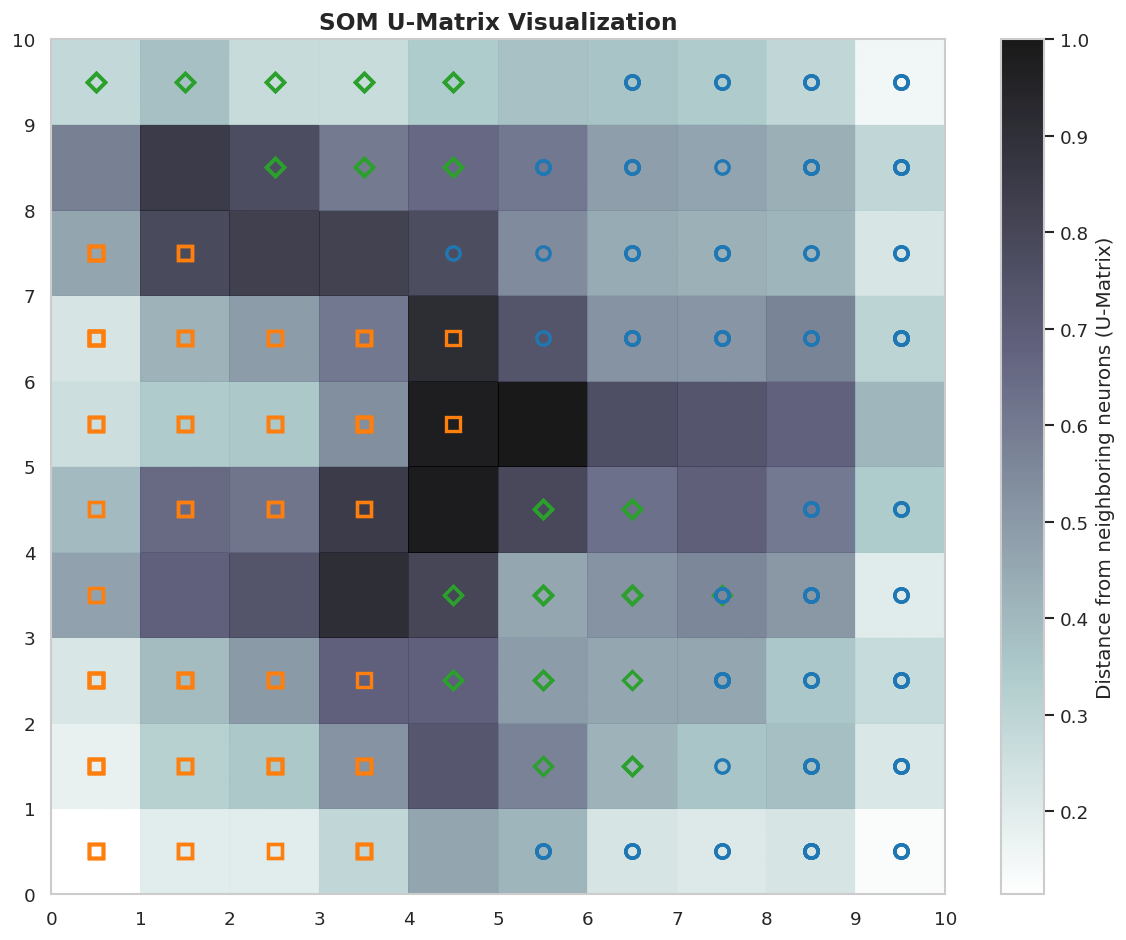

In [8]:
# SOM
from minisom import MiniSom

def train_and_plot_som(X, labels, title, filename, grid_size=(10, 10)):
    """
    Trains a Self-Organizing Map (SOM) and visualizes the U-Matrix (distance map).
    The true class labels are overlaid on the winning neurons to visually evaluate 
    cluster purity and topological preservation.
    The resulting plot is saved in the 'plots' directory with a user-defined filename.
    """
    # 1. Ensure the output directory exists
    if not os.path.exists('plots'):
        os.makedirs('plots')
        
    labels = np.array(labels)
    
    # --- 2. SOM Initialization and Training ---
    # The grid size ensures we meet the assignment requirement of at least 100 neurons.
    # sigma: spread of the neighborhood function
    # learning_rate: initial learning rate
    som = MiniSom(
        x=grid_size[0], 
        y=grid_size[1], 
        input_len=X.shape[1], 
        sigma=1.5, 
        learning_rate=0.5, 
        topology='rectangular',
        random_seed=42
    )
    
    # Initialize weights using PCA to preserve global structure and speed up convergence
    som.pca_weights_init(X)
    
    # Train the model with 2000 iterations to ensure topological stabilization
    print(f"Training SOM for {title}...")
    som.train_random(data=X, num_iteration=2000)
    
    # --- 3. Visualization Setup ---
    # Using a slightly larger figure to accommodate the grid and colorbar comfortably
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # --- 4. Plot the U-Matrix (Distance Map) ---
    # The U-Matrix represents the Euclidean distance between neighboring neurons.
    # - Light colors represent small distances (neurons are similar -> form a cluster).
    # - Dark colors represent large distances (acts as a border/frontier between clusters).
    u_matrix = som.distance_map().T
    pcolor_plot = ax.pcolor(u_matrix, cmap='bone_r', alpha=0.9)
    fig.colorbar(pcolor_plot, ax=ax, label='Distance from neighboring neurons (U-Matrix)')
    
    # --- 5. Overlay True Classes on Winning Neurons ---
    unique_classes = np.unique(labels)
    colors = sns.color_palette("tab10", len(unique_classes))
    
    # Define distinct markers for visual clarity
    markers = ['o', 's', 'D', '^', 'v', 'p', '*', 'X']
    
    for i, data_point in enumerate(X):
        # Find the winning neuron (Best Matching Unit) for the current data point
        w = som.winner(data_point)
        
        # Identify the true class and its designated color/marker
        true_class = labels[i]
        class_idx = np.where(unique_classes == true_class)[0][0]
        
        # Plot the marker at the center of the winning neuron cell (+0.5 offset)
        ax.plot(
            w[0] + 0.5, 
            w[1] + 0.5, 
            markers[class_idx % len(markers)], 
            markerfacecolor='None',
            markeredgecolor=colors[class_idx], 
            markersize=8, 
            markeredgewidth=2
        )
        
    # --- 6. Final Layout adjustments ---
    ax.set_title(f"{title}", fontsize=14, fontweight='bold')
    ax.set_xticks(np.arange(grid_size[0] + 1))
    ax.set_yticks(np.arange(grid_size[1] + 1))
    ax.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()
    
    # --- 7. Save the figure with the exact name provided by the user ---
    save_path = os.path.join('plots', filename)
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    print(f"Plot saved successfully at: {save_path}\n")
    
    plt.show()

# --- Execution Block ---

# For the Synthetic Dataset (e.g., 10x10 = 100 neurons)
train_and_plot_som(
    X=X_syn, 
    labels=meta_syn['labels'], 
    title="SOM U-Matrix Visualization", 
    filename="synthetic_som.png",
    grid_size=(10, 10) 
)

# For the Real Dataset (e.g., 12x10 = 120 neurons)
train_and_plot_som(
    X=X_real, 
    labels=meta_real['labels'], 
    title="SOM U-Matrix Visualization", 
    filename="real_som.png",
    grid_size=(10, 10) 
)